In [234]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

# Part I - Logistic Regression for Binary Classification

## Exercise 1 - Load the dataset

* Load the diabetes dataset (`diabetes.csv`)
* Make a 70/30% train test partition of the dataset

*Suggestion:* I suggest you load it with pandas, but make a scikit-learn style dataset ($X$, $y$ numpy arrays)

In [235]:
# your code goes here:
raw = pd.read_csv("diabetes.csv")
raw

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [236]:
X = raw.values[:,:-1]
y = raw.values[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.7)

## Excercise 2 - Implementing Logistic Regression

* In this exercise you will implement the logistic regression algorithm to learn the vector of weights $\vec{w}$.
* You will then plot the ROC curve, and calculate the AUROC (Area Under the ROC curve) using `sklearn.metrics.roc_auc_score()` for the testing set.

You can follow the structure for gradient descent as described in the previous labs and slides. Don't forget to write a function that calculates the sigmoid. You are not allowed in this exercise to use any existing functions.
* **Note that:** in the book and slides `y` is written as `t` and `y_hat` as `y`. 

Remember that $\nabla E(w) = \sum_{n=1}^N (y_n - t_n)\phi_n$ 

* _Tip:_ plot the loss during training to verify that everything is working properly.

In [237]:
def sigmoid(a):
    result = 1 / (1 + np.exp(-a))
    return result

In [238]:
def CrossEntropy(target, predicted):
    result = - np.sum(target * np.log(predicted + 1e-10) + (1 - target) * np.log(1 - predicted + 1e-10))
    return result

In [239]:
# your code goes here:
# implement logistic regression using numpy following: $\nabla E(w) = \sum_{n=1}^N (y_n - t_n)\phi_n$ 

def SthocasticGradientDescendent(X, y, lr, max_iter):
    n_sample, n_features = X.shape
    np.random.seed(0)
    w = np.random.normal(scale= 0.1, size= n_features)
    error_historic = []

    for i  in range(max_iter):

        for j in range(n_sample):
            
            wt = w - lr * (sigmoid(w @ X[j]) - y[j]) * X[j]
            w = wt

        ce = CrossEntropy(y, sigmoid(X @ w))
        error_historic.append(ce)

    return w, error_historic

In [240]:
w_trained, error_historic = SthocasticGradientDescendent(X_train, y_train, 0.00013, 200)

Evaluate the performance of your model, plot the ROC curve and calculate the AUROC

In [241]:
from sklearn.metrics import roc_auc_score

In [242]:
def roc_curve(X_train, w_trained, target):
    result = sigmoid(X_train @ w_trained)
    threshold = np.unique(result)
    data_tpr = np.zeros(result.size)
    data_fpr = np.zeros(result.size)
    
    for i, t in enumerate(threshold):
        result_copy = result.copy()
        result_copy[result_copy >= t] = 1
        result_copy[result_copy < t] = 0
        
        TP = result_copy @ target
        FP = result_copy @ (1 - target)
        TN = (1 - result_copy) @ (1 - target)
        FN = (1 - result_copy) @ target
        
        data_tpr[i] = TP/(TP + FN)
        data_fpr[i] = FP/(FP + TN)
        
    return data_tpr, data_fpr 

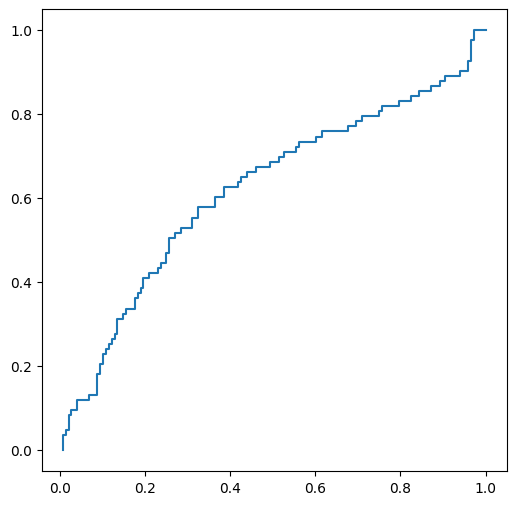

In [243]:
tpr, fpr = roc_curve(X_test, w_trained, y_test)
fig = plt.figure(figsize= (6,6))
plt.plot(fpr, tpr)

In [244]:
roc_auc_score(y_test, sigmoid(X_test @ w_trained))

0.6195050472158905

In [245]:
# your code goes here: 


# Part IV - Logistic Regression for multi-class classification

## Exercise 1 - Load the dataset
* Load the famous Iris dataset (using sklearn as shown below)
* Load the data in a matrix $X$ and the target in a vector $y$.
* Make a 70/30% train test partition of the dataset

In [246]:
from sklearn.datasets import load_iris

In [247]:
iris = load_iris()

Prepare $X$ and $y$

In [248]:
# your code goes here:
X = iris["data"]
y = iris["target"]

Split the data

In [249]:
# your code goes here:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.7, random_state= 12)

In [250]:
y_test

array([0, 2, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 0, 0, 1, 2, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 2, 1, 1, 0, 0, 0, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0])

## Exercise 2 - Train the Logistic Regression model
Train your LogisticRegression multi-class classifier using the sklearn implementation. 
* To use the cross entropy loss function and softmax activation function, the `multi_class` parameter needs to be set to "multinomial"

In [251]:
from sklearn.linear_model import LogisticRegression

In [252]:
# Let's create an instance of the LogisticRegression classifier for multiclass classification
lr_iris = LogisticRegression(solver='newton-cg')

Fit the data

In [253]:
# your code goes here: 
lr_iris.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Exercise 3 - Make predictions and evaluate the model
Use the `predict_proba()` method to obtain the output of the predictions for the testing set. The values are the output of the softmax activation function. 
* Remember that the highest value of each prediction corresponds to the actual predicted class.
* Write a function `get_predicted_class()` that transforms the vector of softmax outputs (obtained from `predict_proba()`) to a vector that just contains the predicted class. 
    - This function takes as input a matrix $\hat{Y}_{proba} \in \mathbb{R}^{m\times k}$ where $m$ is the number of samples in the testing set and $k$ is the number of classes.

As an example: if the softmax output is as follows: `Y_pred_sm = [[0.1,0.2,0.7], [0.4,0.3,0.3]]`, then `get_predicted_class(Y_pred_sm)` should return: `[2,0]` as the highest value for the 1st prediction is class 2 and for the 2nd prediction is class 0.

In [254]:
# complete the input argument for the function to obtain the predictions for the testing set.
y_pred_sm = lr_iris.predict_proba(X_test)
# y_pred = get_predicted_class(y_pred_sm)
y_pred_sm[0]

array([9.79860206e-01, 2.01397334e-02, 6.04266040e-08])

In [255]:
def get_predicted_class(Y_proba):
    y_predicted = np.argmax(Y_proba, axis= 1)
        
    return y_predicted

In [256]:
y_test_result = get_predicted_class(y_pred_sm)
y_test_result

array([0, 2, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 0, 0, 1, 2, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 2, 2, 1, 0, 0, 0, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0])

Now calculate the accuracy in the testing set using `y_pred`
- Try calculating the accuracy without using the sklearn function :)

In [257]:
def accuracy(target, y_predicted):
    result_copy = y_predicted.copy()
    TP = 0
    
    for classe in np.unique(target):
        TP += (result_copy == classe).astype(int) @ (target == classe).astype(int)
        
    return TP/target.size
    
        

In [258]:
np.unique(y_test)

array([0, 1, 2])

In [259]:
accuracy(y_test, y_test_result)

np.float64(0.9777777777777777)

In [260]:
print(y_test)
print(y_test_result)

[0 2 0 1 2 2 2 0 2 0 1 0 0 0 1 2 2 1 0 1 0 1 2 1 0 2 1 1 0 0 0 1 2 0 2 0 1
 1 0 1 1 0 0 0 0]
[0 2 0 1 2 2 2 0 2 0 1 0 0 0 1 2 2 1 0 1 0 1 2 1 0 2 2 1 0 0 0 1 2 0 2 0 1
 1 0 1 1 0 0 0 0]
